In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
from functools import partial
from mad.configs import EARTH_SETTINGS, V1, V1_guidance
from mad.objs import Planet, PlanetConfig
from mad.objs import CruiseMissile, CruiseMissileConfig
from mad.guidances import CruiseWaypointGuidance, CruiseGuidanceConfig, GuidanceManager, NoGuidance, PurePursuitGuidance
from mad.guidances.interrupt_guidances import interrupt_at_linear_distance_to_target
from mad.simulation import Simulation
from mad.utils.logger import SourceLogger
from mad.utils.plotters import plot_2D_planet_with_points

logger = SourceLogger()

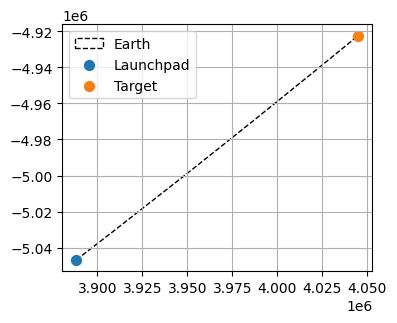

In [3]:
EARTH_SETTINGS["position"] = [0.0, 0.0]

launchsite_target_distance_km = 200
earth = Planet(PlanetConfig(**EARTH_SETTINGS))
launchpad = earth.random_point_at_surface(name="Launchpad", altitude=10)
target = earth.point_at_distance(launchpad, distance_km=launchsite_target_distance_km, name="Target")
waypoints = [launchpad, target]
plot_2D_planet_with_points(earth, points = waypoints, display="arc");

In [4]:
V1, V1_guidance

({'name': 'V-1',
  'mass': 2150.0,
  'ref_radius': 0.3,
  'Cd': 0.5,
  'thrust_acc': 30.0,
  'max_range_m': 250000,
  'yield_kt': 0.0},
 {'max_speed_m_s': 177.77777777777777,
  'altitude_settling_time_s': 60.0,
  'cruise_altitude_m': 900.0})

In [9]:
guidance_config = CruiseGuidanceConfig(waypoints=waypoints, **V1_guidance)
flight = CruiseWaypointGuidance(planet = earth, 
                                target=target, 
                                config=guidance_config, 
                                interrupt_fn=partial(interrupt_at_linear_distance_to_target, reached_distance_m=2_000))

fall = PurePursuitGuidance(planet=earth, target=target)
guidance_manager = GuidanceManager(guidances=[flight, fall])

V1_missile = CruiseMissile(position=launchpad.position.copy(), config=CruiseMissileConfig(**V1, guidance=guidance_manager))
    

19:04:44 | INFO     | Guidance     | CruiseWaypointGuidance: spline built over 2 waypoints (3 dense points), total arc length 200.0 km.


In [10]:
dt = 1.0
max_time = 5_000.0  # enough for 10 000 km at ~250 m/s

sim = Simulation(max_time=max_time, dt=dt)
sim.run(
    planet=earth,
    moving_objs=[V1_missile],
)

df = sim.results


19:04:45 | INFO     | Simulation   | 0.00s - Starting simulation.
19:04:45 | INFO     | Guidance     | Switching to guidance law 1: PurePursuitGuidance
19:04:45 | INFO     | Missile      | 1051.00s - V-1 hit the ground.
19:04:45 | INFO     | Simulation   | 1051.00s - Simulation ended. Took 0.51 s of real time.


In [11]:
df["altitude_km"] = df["position"].apply(lambda pos: (np.linalg.norm(pos) - earth.radius) / 1e3)
df["energy_kJ"] = df["speed"].apply(lambda speed: 0.5 * speed**2 / 1e3)
df["gamma_deg"] = df["gamma"].apply(lambda g: np.degrees(g) if g is not None else None)
df = df.sort_values(by=["name", "time"])

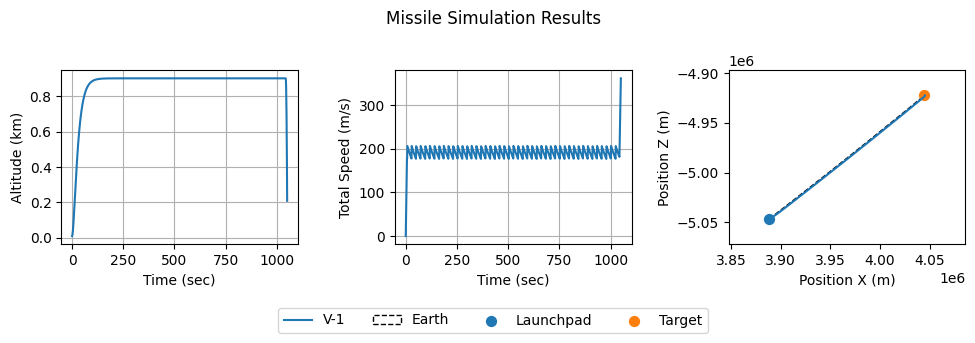

In [13]:
fig, ax = plt.subplots(ncols=3, nrows=1, figsize=(10, 3))
ax = ax.ravel()

sns.lineplot(data=df, x="time", y="altitude_km", hue="name", ax=ax[0])
sns.lineplot(data=df, x="time", y="speed", hue="name", ax=ax[1])
sns.lineplot(data=df, x="posx", y="posz", hue="name", ax=ax[2], sort=False, errorbar=None)

ax[0].set_xlabel("Time (sec)")
ax[0].set_ylabel("Altitude (km)")

ax[1].set_xlabel("Time (sec)")
ax[1].set_ylabel("Total Speed (m/s)")


plot_2D_planet_with_points(earth, points = [launchpad, target], ax=ax[2], display="arc")
ax[2].set_xlabel("Position X (m)")
ax[2].set_ylabel("Position Z (m)")
ax[2].set_aspect("equal", adjustable="datalim")

for a in ax:
    a.grid()
    a.legend()
    handles, labels = a.get_legend_handles_labels()
    a.legend().remove()

fig.suptitle("Missile Simulation Results")
fig.legend(handles, labels, loc="lower center", ncol=4, bbox_to_anchor=(0.5, -0.12))
fig.tight_layout(pad=1.2)